In [1]:
import os, gc, json, time, random, re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset
from collections import Counter

from sklearn.model_selection import GroupShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.metrics.pairwise import cosine_similarity

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from peft import LoraConfig, get_peft_model, TaskType

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ⚠️ MuRIL — Bangla-specific model
MODEL_NAME = "google/muril-base-cased"
print(f"Model: {MODEL_NAME}")

os.makedirs("../results/models", exist_ok=True)
os.makedirs("../results/figures", exist_ok=True)

Device: cuda
Model: google/muril-base-cased


In [2]:
train_df = pd.read_csv("../data/processed/train_hard2.csv")
test_df  = pd.read_csv("../data/processed/test_hard2.csv")

labels = sorted(train_df["label"].unique().tolist())
label2id = {l: i for i, l in enumerate(labels)}
id2label = {i: l for l, i in label2id.items()}

print(f"Train: {train_df.shape} | Test: {test_df.shape}")
print(f"Labels: {label2id}")

Train: (4898, 6) | Test: (2107, 6)
Labels: {'normal': 0, 'promo': 1, 'smish': 2}


In [3]:
t0 = time.time()

# ---------- Cluster ----------
vec_campaign = TfidfVectorizer(
    analyzer="char_wb", ngram_range=(3,6),
    max_features=20000, min_df=2, sublinear_tf=True,
)
X_campaign = vec_campaign.fit_transform(train_df["text_clean"].astype(str))

kmeans = KMeans(n_clusters=150, random_state=SEED, n_init=10)
train_df = train_df.copy()
train_df["cluster"] = kmeans.fit_predict(X_campaign)

# ---------- Split ----------
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
train_idx, val_idx = next(gss.split(train_df, groups=train_df["cluster"]))

train_split = train_df.iloc[train_idx].reset_index(drop=True)
val_split   = train_df.iloc[val_idx].reset_index(drop=True)

# ---------- Strict Near-Dup Filter ----------
vec_word = TfidfVectorizer(analyzer='word', ngram_range=(1,3), min_df=2,
                            max_features=15000, sublinear_tf=True)
vec_char = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), min_df=2,
                            max_features=15000, sublinear_tf=True)

X_train_w = vec_word.fit_transform(train_split["text_clean"].astype(str))
X_val_w   = vec_word.transform(val_split["text_clean"].astype(str))
X_train_c = vec_char.fit_transform(train_split["text_clean"].astype(str))
X_val_c   = vec_char.transform(val_split["text_clean"].astype(str))

sim_w = cosine_similarity(X_val_w, X_train_w).max(axis=1)
sim_c = cosine_similarity(X_val_c, X_train_c).max(axis=1)

keep_mask = (sim_w < 0.55) & (sim_c < 0.80)
val_split_clean = val_split[keep_mask].reset_index(drop=True)

print(f"[{time.time()-t0:.1f}s] Train: {train_split.shape} | Val: {len(val_split_clean)}")

# ---------- Augmentation ----------
def augment(text):
    if "[URL]" in text and random.random() < 0.5:
        text = text.replace("[URL]", "").strip()
    if "[PHONE]" in text and random.random() < 0.5:
        text = text.replace("[PHONE]", "").strip()
    words = text.split()
    if len(words) > 5 and random.random() < 0.2:
        i, j = random.sample(range(len(words)), 2)
        words[i], words[j] = words[j], words[i]
        text = " ".join(words)
    return text

random.seed(SEED)
aug_rows = []
for _, row in train_split.iterrows():
    for _ in range(2):
        new_row = row.copy()
        new_text = augment(row["text_clean"])
        if new_text != row["text_clean"]:
            new_row["text_clean"] = new_text
            aug_rows.append(new_row)

train_aug = pd.concat([train_split, pd.DataFrame(aug_rows)], ignore_index=True)
train_aug = train_aug.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"Augmented train: {train_aug.shape}")

[70.3s] Train: (4065, 7) | Val: 623
Augmented train: (6798, 7)


In [4]:
# ⚠️ MuRIL tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
MAX_LEN = 128

print(f"Tokenizer vocab: {tokenizer.vocab_size}")

# Test tokenization on Bengali
sample = "আপনার bKash একাউন্ট ভেরিফাই করুন [URL]"
tokens = tokenizer.tokenize(sample)
print(f"\nSample tokens: {tokens[:15]}")


class SMSDataset(Dataset):
    def __init__(self, df, tokenizer, label2id, max_len=128):
        self.texts = df["text_clean"].astype(str).tolist()
        self.labels = [label2id[l] for l in df["label"]]
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(self.texts[idx], truncation=True,
                              padding="max_length", max_length=self.max_len)
        enc["labels"] = self.labels[idx]
        return enc


train_ds = SMSDataset(train_aug, tokenizer, label2id, MAX_LEN)
val_ds   = SMSDataset(val_split_clean, tokenizer, label2id, MAX_LEN)
test_ds  = SMSDataset(test_df, tokenizer, label2id, MAX_LEN)

# Class weights
label_counts = Counter(train_aug["label"].map(label2id))
total = sum(label_counts.values())
class_weights = {i: total / (len(labels) * label_counts[i]) for i in range(len(labels))}

print(f"\nTrain: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
print("Class weights:", class_weights)

config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

c:\Users\User\Desktop\research\venv\Lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\models--google--muril-base-cased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/3.16M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

Tokenizer vocab: 197258

Sample tokens: ['আপনার', 'b', '##K', '##ash', 'একাউন্ট', 'ভ', '##েরি', '##ফাই', 'করুন', '[', 'URL', ']']

Train: 6798 | Val: 623 | Test: 2107
Class weights: {0: 1.0361225422953817, 1: 1.2416438356164383, 2: 0.8133524766690596}


In [6]:
def compute_metrics(eval_pred):
    logits, y_true = eval_pred
    y_pred = np.argmax(logits, axis=-1)
    return {
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "accuracy": accuracy_score(y_true, y_pred),
    }

class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        y = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        w = torch.tensor([self.class_weights[i] for i in range(len(self.class_weights))],
                          device=logits.device, dtype=torch.float32)
        loss = nn.CrossEntropyLoss(weight=w)(logits, y)
        return (loss, outputs) if return_outputs else loss


gc.collect()
torch.cuda.empty_cache()

# ---------- MuRIL Base Model ----------
base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(labels),
    id2label=id2label, label2id=label2id,
)

# ---------- LoRA r=16 (best from ablation) ----------
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,
    lora_alpha=32,
    lora_dropout=0.2,
    bias="none",
    target_modules=["query", "key", "value", "dense"],
)
model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

# ---------- Training Args ----------
training_args = TrainingArguments(
    output_dir="../results/models/muril_lora_r16",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=1,
    num_train_epochs=3,
    weight_decay=0.05,
    warmup_steps=0.2,
    max_grad_norm=0.5,
    label_smoothing_factor=0.1,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_macro_f1",
    greater_is_better=True,
    logging_steps=100,
    save_total_limit=1,
    report_to="none",
    fp16=True,
    optim="adamw_torch_fused",
    dataloader_pin_memory=True,
    seed=SEED,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
    class_weights=class_weights,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2, early_stopping_threshold=0.001)],
)

print("✅ Trainer ready")
print("Train:", len(trainer.train_dataset), "| Eval:", len(trainer.eval_dataset))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google/muril-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params w

trainable params: 2,681,091 || all params: 240,239,622 || trainable%: 1.1160
✅ Trainer ready
Train: 6798 | Eval: 623


In [7]:
train_result = trainer.train()
print("\n✅ MuRIL Training done")

Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,1.064581,1.026515,0.541125,0.635634
2,0.621029,0.573391,0.535213,0.638844
3,0.552530,0.530643,0.525636,0.629213



✅ MuRIL Training done


In [8]:
print("=" * 60)
print("MURIL TEST EVALUATION (B1: URL Holdout)")
print("=" * 60)

test_results = trainer.evaluate(test_ds, metric_key_prefix="test")
print(f"Test Accuracy : {test_results['test_accuracy']:.4f}")
print(f"Test Macro F1 : {test_results['test_macro_f1']:.4f}")

preds_output = trainer.predict(test_ds)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = preds_output.label_ids

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=labels))

smish_idx = label2id["smish"]
smish_mask = y_true == smish_idx
smish_recall = (y_pred[smish_mask] == smish_idx).mean()
smish_precision = (y_true[y_pred == smish_idx] == smish_idx).mean()

print(f"\n>>> SMISH RECALL   : {smish_recall:.4f} <<<")
print(f">>> SMISH PRECISION: {smish_precision:.4f} <<<")

MURIL TEST EVALUATION (B1: URL Holdout)


[transformers] early stopping required metric_for_best_model, but did not find eval_macro_f1 so early stopping is disabled


Training Loss,Validation Loss,Epoch,Macro F1,Accuracy
0.552530,1.014990,3,0.468959,0.430944


Test Accuracy : 0.4309
Test Macro F1 : 0.4690



CLASSIFICATION REPORT
              precision    recall  f1-score   support

      normal       0.84      0.98      0.91       498
       promo       0.23      0.99      0.38       342
       smish       0.95      0.06      0.12      1267

    accuracy                           0.43      2107
   macro avg       0.68      0.68      0.47      2107
weighted avg       0.81      0.43      0.35      2107


>>> SMISH RECALL   : 0.0647 <<<
>>> SMISH PRECISION: 0.9535 <<<


In [9]:
print("=" * 90)
print("BASE MODEL COMPARISON — B1 (URL Holdout)")
print("=" * 90)
print(f"{'Model':30s} | {'Test F1':>10s} | {'Smish Rec':>10s} | {'Improvement':>12s}")
print("-" * 90)

xlmr_f1 = 0.7437
xlmr_smish = 0.5912
muril_f1 = test_results['test_macro_f1']
muril_smish = smish_recall
baseline_f1 = 0.5963

print(f"{'Baseline (TF-IDF+LR)':30s} | {baseline_f1:>10.4f} | {'—':>10s} | {'—':>12s}")
print(f"{'XLM-R + LoRA (r=16)':30s} | {xlmr_f1:>10.4f} | {xlmr_smish:>10.4f} | {xlmr_f1-baseline_f1:>+12.4f} ✅")
print(f"{'MuRIL + LoRA (r=16)':30s} | {muril_f1:>10.4f} | {muril_smish:>10.4f} | {muril_f1-baseline_f1:>+12.4f} 🚨")
print("=" * 90)

print(f"\n📊 Analysis:")
print(f"   XLM-R − MuRIL = {xlmr_f1 - muril_f1:+.4f} F1")
print(f"   XLM-R smish recall advantage: {xlmr_smish - muril_smish:+.4f}")

# Save
muril_results = {
    "model": "MuRIL + LoRA r=16",
    "test_f1": float(muril_f1),
    "test_accuracy": float(test_results['test_accuracy']),
    "smish_recall": float(smish_recall),
    "smish_precision": float(smish_precision),
    "xlmr_f1": xlmr_f1,
    "xlmr_smish_recall": xlmr_smish,
    "baseline_f1": baseline_f1,
    "delta_vs_xlmr": float(muril_f1 - xlmr_f1),
}
with open("../results/muril_comparison.json", "w") as f:
    json.dump(muril_results, f, indent=2)
print("\n✅ Saved: muril_comparison.json")

BASE MODEL COMPARISON — B1 (URL Holdout)
Model                          |    Test F1 |  Smish Rec |  Improvement
------------------------------------------------------------------------------------------
Baseline (TF-IDF+LR)           |     0.5963 |          — |            —
XLM-R + LoRA (r=16)            |     0.7437 |     0.5912 |      +0.1474 ✅
MuRIL + LoRA (r=16)            |     0.4690 |     0.0647 |      -0.1273 🚨

📊 Analysis:
   XLM-R − MuRIL = +0.2747 F1
   XLM-R smish recall advantage: +0.5265

✅ Saved: muril_comparison.json


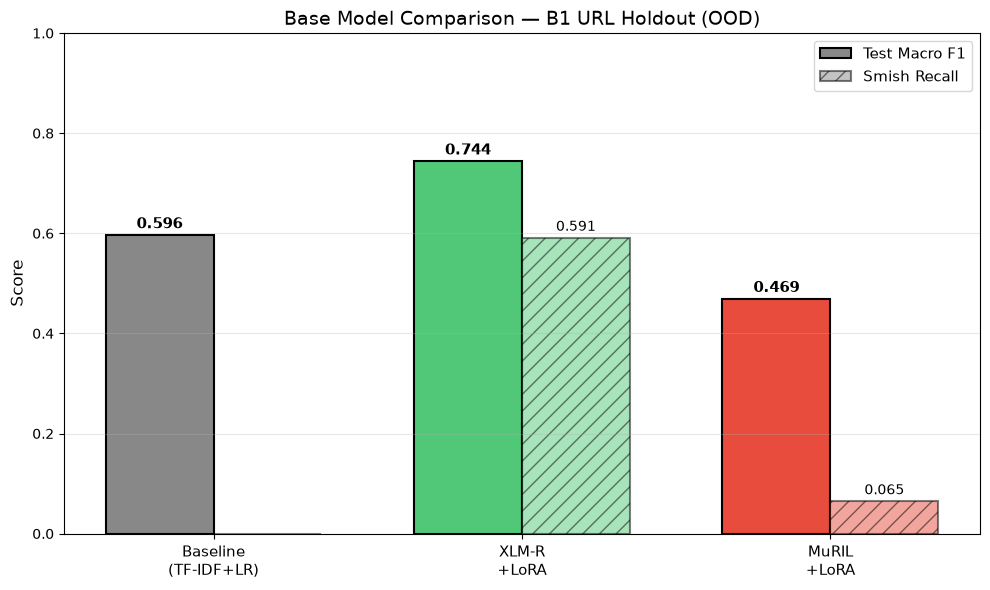

✅ Saved: base_model_comparison.png


: 

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

models = ['Baseline\n(TF-IDF+LR)', 'XLM-R\n+LoRA', 'MuRIL\n+LoRA']
f1_scores = [0.5963, 0.7437, test_results['test_macro_f1']]
smish_recalls = [0, 0.5912, smish_recall]
colors = ['#888888', '#50C878', '#E74C3C']   # MuRIL লাল (খারাপ)

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, f1_scores, width, label='Test Macro F1',
                color=colors, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, smish_recalls, width, label='Smish Recall',
                color=colors, alpha=0.5, edgecolor='black', linewidth=1.5, hatch='//')

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 5), textcoords="offset points",
                ha='center', fontsize=11, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    if height > 0:
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 5), textcoords="offset points",
                    ha='center', fontsize=10)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Base Model Comparison — B1 URL Holdout (OOD)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis='y')
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig("../results/figures/base_model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: base_model_comparison.png")